# PROJET FIL ROUGE
##### Modèle de Machine Learning sur les Jeux Olympiques de 2028 à Los Angeles 

---

### **NETTOYAGE ET PRÉPARATION DES DONNÉES**

##### IMPORT DE L'ENVIRONNEMENT DE TRAVAIL

In [118]:
import pandas as pd

df = pd.read_csv("olympics_dataset.csv")

##### VISUALISATION DES DONNÉES

In [119]:
df.head()

,player_id,Name,Sex,Team,NOC,Year,Season,City,Sport,Event,Medal
0,0,A Dijiang,M,China,CHN,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,1,A Lamusi,M,China,CHN,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No medal
2,2,Gunnar Aaby,M,Denmark,DEN,1920,Summer,Antwerpen,Football,Football Men's Football,No medal
3,3,Edgar Aabye,M,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,26,Cornelia (-strannood),F,Netherlands,NED,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,No medal


In [120]:
df.shape

(252565, 11)

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252565 entries, 0 to 252564
Data columns (total 11 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   player_id  252565 non-null  int64 
 1   Name       252565 non-null  object
 2   Sex        252565 non-null  object
 3   Team       252565 non-null  object
 4   NOC        252565 non-null  object
 5   Year       252565 non-null  int64 
 6   Season     252565 non-null  object
 7   City       252565 non-null  object
 8   Sport      252565 non-null  object
 9   Event      252565 non-null  object
 10  Medal      252565 non-null  object
dtypes: int64(2), object(9)
memory usage: 21.2+ MB


##### VÉRIFICATION DE LA QUALITÉ DES DONNÉES 

In [122]:
df.isna().sum() # vérification des valeurs nulles dans le dataset 

player_id    0
Name         0
Sex          0
Team         0
NOC          0
Year         0
Season       0
City         0
Sport        0
Event        0
Medal        0
dtype: int64

In [123]:
df.duplicated().sum() # vérification des doublons dans le dataset

0

In [124]:
df['player_id'].nunique()

235903

In [125]:
df['Season'].unique() # vérification des colonnes à potentiellement supprimer 

array(['Summer'], dtype=object)

In [126]:
df = df.drop(['Season'], axis=1) # suppression de la colonne Season car 1 seule valeur unique

In [127]:
df["NOC"].nunique() # vérification de la pertinence de la colonne par rapport à Team


234

In [128]:
df["Team"].nunique() # vérification de la pertinence de la colonne par rapport à NOC

1193

##### VALEURS ABERRANTES 

In [129]:
df.head()

,player_id,Name,Sex,Team,NOC,Year,City,Sport,Event,Medal
0,0,A Dijiang,M,China,CHN,1992,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,1,A Lamusi,M,China,CHN,2012,London,Judo,Judo Men's Extra-Lightweight,No medal
2,2,Gunnar Aaby,M,Denmark,DEN,1920,Antwerpen,Football,Football Men's Football,No medal
3,3,Edgar Aabye,M,Denmark/Sweden,DEN,1900,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,26,Cornelia (-strannood),F,Netherlands,NED,1932,Los Angeles,Athletics,Athletics Women's 100 metres,No medal


Year    Axes(0.125,0.747241;0.110714x0.132759)
dtype: object

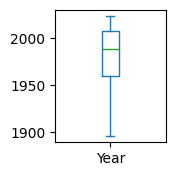

In [130]:
# Visualisation de la seule colonne numérique

df['Year'].plot(
    kind="box",
    subplots=True,
    layout=(5, 6),
    figsize=(10, 10)
)

##### IMPORT DES VALEURS D'ÂGE 

In [131]:
df_info_athlete = pd.read_csv("olympics_age.csv", sep=",")

In [132]:
df_info_athlete = pd.read_csv("olympics_age.csv", sep=",")
display(df_info_athlete.head())

,name,sex,age,medal,year,season,noc,country
0,Dijiang,Male,24.0,NaN,1992,summer,CHN,China
1,Lamusi,Male,23.0,NaN,2012,summer,CHN,China
2,unnar Nielsen Aaby,Male,24.0,NaN,1920,summer,DEN,Denmark
3,dgar Lindenau Aabye,Male,34.0,Gold,1900,summer,DEN,Denmark
4,hristine Jacoba Aaftink,Female,21.0,NaN,1988,winter,NED,Netherlands


In [133]:
df_info_athlete.shape

(300714, 8)

In [134]:
df_info_athlete.isna().sum() # vérification des valeurs nulles dans le dataset 

# On ne peut donc pas merge aussi avec les médailles 

name            0
sex             0
age          9474
medal      256170
year            0
season          0
noc             5
country         5
dtype: int64

In [135]:
# Les NaN de age représente 3.15 % du volume de ce dataset donc on les supprime

df_info_athlete = df_info_athlete.dropna(subset=["age"])

In [136]:
df_summer = df_info_athlete[df_info_athlete['season'] == 'summer']

drop = ['country', 'season']
df_age = df_summer.drop(columns=drop)

# Afficher le résultat pour vérifier
display(df_age.head())

,name,sex,age,medal,year,noc
0,Dijiang,Male,24.0,NaN,1992,CHN
1,Lamusi,Male,23.0,NaN,2012,CHN
2,unnar Nielsen Aaby,Male,24.0,NaN,1920,DEN
3,dgar Lindenau Aabye,Male,34.0,Gold,1900,DEN
26,"ornelia ""Cor"" Aalten (-Strannood)",Female,18.0,NaN,1932,NED


In [137]:
df_age["age"] = df_age["age"].round(0).astype(int)

In [138]:
df_age['sex'] = df_age['sex'].replace({'Male': 'M', 'Female': 'F'})

Étape 1 — Nettoyer les noms dans les deux datasets

In [139]:
import unidecode

def clean_name(x):
    x = unidecode.unidecode(x)          # enlever accents
    x = x.lower().strip()               # enlever les espaces avant et après + tout mettre en minuscule
    x = x.replace("-", " ")             # enlever les tirets
    x = " ".join(x.split())             # normaliser espaces
    return x

# Appliquer aux deux datasets df_age et df

df["clean_name"] = df["Name"].apply(clean_name)
df_age["clean_name"] = df_age["name"].apply(clean_name)

Étape 2 — Extraire le nom de famille proprement

In [140]:
# Etraire les noms pour les merger ensuite 

df["last_name"] = df["clean_name"].str.split().str[-1]
df_age["last_name"] = df_age["clean_name"].str.split().str[-1]

Étape 3 — Merge souple (sans Medal)

In [141]:
df = df.merge(
    df_age.rename(columns={
        "last_name": "last_name",
        "sex": "Sex",
        "noc": "NOC",
        "year": "Year",
        "age": "Age"
    })[["last_name", "Sex", "NOC", "Year", "Age"]],
    on=["last_name", "Sex", "NOC", "Year"],
    how="left"
)


In [142]:
df.head()

,player_id,Name,Sex,Team,NOC,Year,City,Sport,Event,Medal,clean_name,last_name,Age
0,0,A Dijiang,M,China,CHN,1992,Barcelona,Basketball,Basketball Men's Basketball,No medal,a dijiang,dijiang,24.0
1,1,A Lamusi,M,China,CHN,2012,London,Judo,Judo Men's Extra-Lightweight,No medal,a lamusi,lamusi,23.0
2,2,Gunnar Aaby,M,Denmark,DEN,1920,Antwerpen,Football,Football Men's Football,No medal,gunnar aaby,aaby,24.0
3,3,Edgar Aabye,M,Denmark/Sweden,DEN,1900,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,edgar aabye,aabye,34.0
4,26,Cornelia (-strannood),F,Netherlands,NED,1932,Los Angeles,Athletics,Athletics Women's 100 metres,No medal,cornelia ( strannood),strannood),18.0


In [143]:
1 - df["Age"].isna().mean()

# 94.06 % de matching réussi

0.9406465717929513

In [144]:
df.isna().sum() # vérification des valeurs nulles dans le dataset 

# Les valeurs nulles des âges représentent 6%. On attend de filtrer les années à > 1960, avant de prendre une décision.

player_id         0
Name              0
Sex               0
Team              0
NOC               0
Year              0
City              0
Sport             0
Event             0
Medal             0
clean_name        0
last_name         0
Age           38116
dtype: int64

##### ENCODAGE DES DONNÉES (Sex, Medal)

In [145]:
df['Sex'].unique()

array(['M', 'F'], dtype=object)

In [146]:
df["Sex_encoded"] = df["Sex"].map({"M": 1, "F": 0}) # encodage de Sex pour faciliter la création des champs 

In [147]:
df["Medal"].unique()

array(['No medal', 'Gold', 'Bronze', 'Silver'], dtype=object)

In [148]:
# Normalisation de Medal

df["Medal"] = df["Medal"].str.strip().str.lower()
df["Medal"] = df["Medal"].fillna("no medal")

In [149]:
# Encodage réaliste des médailles

df["Medal_encode"] = df["Medal"].map({
    "no medal": 0,
    "bronze": 1,
    "silver": 2,
    "gold": 3
})

In [150]:
df["Medal_score"] = df.groupby("player_id")["Medal_encode"].cumsum()

##### CRÉATION DE NOUVEAUX CHAMPS 

1. FEATURES ATHLÈTES

In [151]:
# Indicateur binaire : l’athlète a-t-il gagné une médaille ?
df["has_medal"] = (df["Medal_score"] > 0).astype(int)

In [152]:
# Durée de carrière olympique (première → dernière participation)

'''df["histo_athlete_years"] = (
    df.groupby("player_id")["Year"]
      .transform(lambda x: x.max() - x.min())
)'''

'df["histo_athlete_years"] = (\n    df.groupby("player_id")["Year"]\n      .transform(lambda x: x.max() - x.min())\n)'

In [153]:
# Nombre total de participations par athlète

df["particip_athlete"] = (
    df.groupby("Name")["Year"]
      .transform("count")
)

In [154]:
# Nombre d’équipes distinctes par athlète, pays, année

df["nb_team"] = (
    df.groupby(["Name", "NOC", "Year"])["Team"]
      .transform("nunique")
)

In [155]:
# Score médaille total par athlète

df["medal_score_athlete_total"] = (
    df.groupby("player_id")["Medal_score"]
      .transform("sum")
)

In [156]:
# Nombre total de médailles par athlète

df["nb_medal_athlete"] = (
    df.groupby("player_id")["has_medal"]
      .transform("sum")
)

In [157]:
# Nombre de médailles cumulées AVANT l'édition actuelle : cela permet d'avoir le chemin de médaille par athlète au fil des années de participation

df["evol_medal_athlete"] = (
    df.groupby("player_id")["has_medal"]
      .transform(lambda x: x.shift(1).cumsum().fillna(0))
)

2. FEATURES PAYS (NOC)

In [158]:
# Nombre total de participations par pays (années distinctes)

df["particip_pays"] = (
    df.groupby("NOC")["Year"]
      .transform("nunique")
)

In [159]:
# Nombre d’athlètes distincts par pays et année

df["nb_athlete_country"] = (
    df.groupby(["NOC", "Year"])["Name"]
      .transform("nunique")
)

In [160]:
# Nombre total de sports distincts par pays

df["nb_sport_country"] = (
    df.groupby(["NOC", "Year"])["Sport"]
      .transform("nunique")
)

In [161]:
# Score médaille total par pays

df["medal_score_country_total"] = (
    df.groupby(["NOC", "Year"])["Medal_score"]
      .transform("sum")
)

In [162]:
# Nombre total de médailles par pays

df["nb_medal_country"] = (
    df.groupby("NOC")["has_medal"]
      .transform("sum")
)

In [163]:
# Nombre de médailles cumulées : : cela permet d'avoir le chemin de médaille par athlète au fil des années de participation
# Pour chaque pays et chaque année, on calcule combien de médailles il avait AVANT cette année.

country_yearly = (
    df.groupby(["NOC", "Year"])[["has_medal", "Medal_score"]]
      .sum()
      .sort_values(["NOC", "Year"])
      .reset_index()
)

country_yearly["evol_medal_country"] = (
    country_yearly.groupby("NOC")["has_medal"]
    .transform(lambda x: x.shift(1).cumsum().fillna(0))
)

In [164]:
df = df.merge(
    country_yearly[["NOC", "Year", "evol_medal_country"]],
    on=["NOC", "Year"],
    how="left"
)

In [165]:
# Calcul du Ratio médaille / pays 

country_yearly = (
    df.groupby(["NOC", "Year"])
      .agg(
          nb_athletes=("player_id", "nunique"),
          nb_medals=("has_medal", "sum")
      )
      .reset_index()
)

In [166]:
# Taux de médaille par pays et par année

country_yearly["medal_rate"] = (
    country_yearly["nb_medals"] / country_yearly["nb_athletes"]
)

# Ce taux varie entre 0 et 1
# Il capture l’efficacité du pays

In [167]:
# Ratio : Athlètes moyens / Taux de médaille

country_yearly["athlete_medal_ratio"] = (
    country_yearly["nb_athletes"] / (country_yearly["medal_rate"] + 1e-6)
)

# Ajout de 1e-6 pour éviter une division par zéro quand un pays n’a aucune médaille une année.

In [168]:
df = df.merge(
    country_yearly[[
        "NOC", "Year",
        "nb_athletes",
        "nb_medals",
        "medal_rate",
        "athlete_medal_ratio"
    ]],
    on=["NOC", "Year"],
    how="left"
)

5. PARTIE HÔTE

In [169]:
host_countries = {
    1896: "GRE",
    1900: "FRA",
    1904: "USA",
    1908: "GBR",
    1912: "SWE",
    1920: "BEL",
    1924: "FRA",
    1928: "NED",
    1932: "USA",
    1936: "GER",
    1948: "GBR",
    1952: "FIN",
    1956: "AUS",
    1960: "ITA",
    1964: "JPN",
    1968: "MEX",
    1972: "GER",
    1976: "CAN",
    1980: "URS",
    1984: "USA",
    1988: "KOR",
    1992: "ESP",
    1996: "USA",
    2000: "AUS",
    2004: "GRE",
    2008: "CHN",
    2012: "GBR",
    2016: "BRA",
    2020: "JPN",
    2024: "FRA",
}

In [170]:
host_df = pd.DataFrame.from_dict(
    host_countries,
    orient="index",
    columns=["host_NOC"]
)
host_df.index.name = "Year"

In [171]:
df = df.merge(host_df, on="Year", how="left")

In [172]:
df["is_host_country"] = (df["NOC"] == df["host_NOC"]).astype(int)

In [173]:
df["host_NOC"] = df["host_NOC"].fillna("UNK")

6. FILTRE RECENT : conserver des athlètes potentiellement toujours en activité

In [174]:
from datetime import datetime

In [175]:
current_year = datetime.now().year # définir current_year

In [176]:
# Calculer l’année de première participation de chaque athlète

df["first_year_athlete"] = df.groupby("player_id")["Year"].transform("min")
df["years_since_first"] = current_year - df["first_year_athlete"]

In [177]:
# Créer un champ pour identifier les athlètes encore “récents”, qui ont un nombre d'année jusqu'à aujourd'hui inférieur à 20.

df["recent_athlete"] = (df["years_since_first"] <= 20).astype(int)

##### VÉRIFICATION DES CHAMPS CRÉÉS

In [178]:
print(df.shape)
print(df.columns)

(642187, 37)
Index(['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport',
       'Event', 'Medal', 'clean_name', 'last_name', 'Age', 'Sex_encoded',
       'Medal_encode', 'Medal_score', 'has_medal', 'particip_athlete',
       'nb_team', 'medal_score_athlete_total', 'nb_medal_athlete',
       'evol_medal_athlete', 'particip_pays', 'nb_athlete_country',
       'nb_sport_country', 'medal_score_country_total', 'nb_medal_country',
       'evol_medal_country', 'nb_athletes', 'nb_medals', 'medal_rate',
       'athlete_medal_ratio', 'host_NOC', 'is_host_country',
       'first_year_athlete', 'years_since_first', 'recent_athlete'],
      dtype='object')


In [179]:
df.head()

,player_id,Name,Sex,Team,NOC,Year,City,Sport,Event,Medal,...,evol_medal_country,nb_athletes,nb_medals,medal_rate,athlete_medal_ratio,host_NOC,is_host_country,first_year_athlete,years_since_first,recent_athlete
0,0,A Dijiang,M,China,CHN,1992,Barcelona,Basketball,Basketball Men's Basketball,no medal,...,326.0,394,330,0.837563,470.411560,ESP,0,1992,34,0
1,1,A Lamusi,M,China,CHN,2012,London,Judo,Judo Men's Extra-Lightweight,no medal,...,2066.0,479,290,0.605428,791.174555,GBR,0,2012,14,1
2,2,Gunnar Aaby,M,Denmark,DEN,1920,Antwerpen,Football,Football Men's Football,no medal,...,635.0,246,336,1.365854,180.107011,BEL,0,1920,106,0
3,3,Edgar Aabye,M,Denmark/Sweden,DEN,1900,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,gold,...,39.0,36,27,0.750000,47.999936,FRA,0,1900,126,0
4,26,Cornelia (-strannood),F,Netherlands,NED,1932,Los Angeles,Athletics,Athletics Women's 100 metres,no medal,...,410.0,80,30,0.375000,213.332764,USA,0,1932,94,0


In [180]:
df.shape

(642187, 37)

##### FILTRES 

In [181]:
df = df[df["Age"] < 45]

In [182]:
df = df[df["Year"] > 1960]

In [183]:
df.isna().sum() # vérification des valeurs nulles dans le dataset 

player_id                    0
Name                         0
Sex                          0
Team                         0
NOC                          0
Year                         0
City                         0
Sport                        0
Event                        0
Medal                        0
clean_name                   0
last_name                    0
Age                          0
Sex_encoded                  0
Medal_encode                 0
Medal_score                  0
has_medal                    0
particip_athlete             0
nb_team                      0
medal_score_athlete_total    0
nb_medal_athlete             0
evol_medal_athlete           0
particip_pays                0
nb_athlete_country           0
nb_sport_country             0
medal_score_country_total    0
nb_medal_country             0
evol_medal_country           0
nb_athletes                  0
nb_medals                    0
medal_rate                   0
athlete_medal_ratio          0
host_NOC

##### VIF : GESTION DES FEATURES REDONDANTES (détecter la multicolinéarité entre les variables quantitatives)

In [184]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

In [185]:
df.columns

Index(['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport',
       'Event', 'Medal', 'clean_name', 'last_name', 'Age', 'Sex_encoded',
       'Medal_encode', 'Medal_score', 'has_medal', 'particip_athlete',
       'nb_team', 'medal_score_athlete_total', 'nb_medal_athlete',
       'evol_medal_athlete', 'particip_pays', 'nb_athlete_country',
       'nb_sport_country', 'medal_score_country_total', 'nb_medal_country',
       'evol_medal_country', 'nb_athletes', 'nb_medals', 'medal_rate',
       'athlete_medal_ratio', 'host_NOC', 'is_host_country',
       'first_year_athlete', 'years_since_first', 'recent_athlete'],
      dtype='object')

In [ ]:
# Sélection des colonnes et suppression feature par feature selon les résultats du VIF

cols_vif = ['Age', 'Sex_encoded','Medal_encode', 'Medal_score', 'has_medal', 
       'particip_athlete', 'nb_team', 'medal_score_athlete_total', 'nb_medal_athlete',
       'evol_medal_athlete', 'particip_pays', 
       'nb_sport_country', 'medal_score_country_total', 'nb_medal_country',
       'evol_medal_country', 'nb_athletes', 'nb_medals', 'medal_rate',
       'athlete_medal_ratio', 'is_host_country', 
       'years_since_first', 'recent_athlete']

# Colonnes supprimées : 'first_year_athlete', 'nb_athlete_country', 'Year'.

In [204]:
X = df[cols_vif]

In [205]:
# Calcul des VIF  

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [VIF(X.values, i) for i in range(X.shape[1])]
vif["Precision"] = [1 - 1/VIF(X.values, i) for i in range(X.shape[1])]

vif.sort_values("VIF", ascending=False)


,feature,VIF,Precision
16,nb_medals,51.750665,0.980677
11,nb_sport_country,50.296504,0.980118
6,nb_team,44.276525,0.977415
15,nb_athletes,38.055135,0.973722
13,nb_medal_country,29.325886,0.965900
14,evol_medal_country,24.095840,0.958499
0,Age,21.918765,0.954377
3,Medal_score,20.199868,0.950495
17,medal_rate,19.065381,0.947549
9,evol_medal_athlete,18.547828,0.946085


In [206]:
df.columns

Index(['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport',
       'Event', 'Medal', 'clean_name', 'last_name', 'Age', 'Sex_encoded',
       'Medal_encode', 'Medal_score', 'has_medal', 'particip_athlete',
       'nb_team', 'medal_score_athlete_total', 'nb_medal_athlete',
       'evol_medal_athlete', 'particip_pays', 'nb_athlete_country',
       'nb_sport_country', 'medal_score_country_total', 'nb_medal_country',
       'evol_medal_country', 'nb_athletes', 'nb_medals', 'medal_rate',
       'athlete_medal_ratio', 'host_NOC', 'is_host_country',
       'first_year_athlete', 'years_since_first', 'recent_athlete'],
      dtype='object')

In [207]:
num_cols = ['Age', 'Sex_encoded','Medal_encode', 'Medal_score', 'has_medal', 
       'particip_athlete', 'nb_team', 'medal_score_athlete_total', 'nb_medal_athlete',
       'evol_medal_athlete', 'particip_pays', 
       'nb_sport_country', 'medal_score_country_total', 'nb_medal_country',
       'evol_medal_country', 'nb_athletes', 'nb_medals', 'medal_rate',
       'athlete_medal_ratio', 'is_host_country', 
       'years_since_first', 'recent_athlete']


quali_cols = ['Sex', 'NOC','Sport', 'Medal', 'host_NOC']

context_cols = ['player_id', 'Name', 'Team', 'City', 'Event', 'City', 'clean_name', 'last_name']

---

### **ANALYSE DES DONNÉES**


---

### **CONSTRUCTION DU MODÈLE DE MACHINE LEARNING**

---

### **CRÉATION ET MISE EN PLACE DASHBOARD**